# Chem Data Experiments

## Loading libraries and data

In [1]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA
from tabulate import tabulate

# Import functions from Chen et. al.
from graph_active_learning_functions import *

In [2]:
# Load all data and set constants

# CuSO4 (exponentially distributed)
samples = 1000
iters = 100
X_chem, S_gt_chem, A_gt_chem = load_data(name = 'synth_chem_data.npy', typename = 'chem')

# FeSO4
X_chem_FeSO4, S_gt_chem_FeSO4, A_gt_chem_FeSO4 = load_data(name = 'synth_FeSO4_data.npy', typename = 'chem')

# CuSO4
X_chem_CuSO4, S_gt_chem_CuSO4, A_gt_chem_CuSO4 = load_data(name = 'synth_CuSO4_data.npy', typename = 'chem')

# FeCl3
X_chem_FeCl3, S_gt_chem_FeCl3, A_gt_chem_FeCl3 = load_data(name = 'synth_FeCl3_data.npy', typename = 'chem')


Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1000, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1000, 2)

First chemical's concentration in X (how much of class 1?):
 1.1670295769786863
<class 'numpy.ndarray'>
(1000, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1000, 1000)
Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 3.180254164124069
<class 'numpy.ndarray'>
(1050, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1050, 1000)
Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 1.13899

## CuSO4 (exponentially distributed)

### Quick param testing

In [ ]:
# GLU

# Best RMSE + SAD: 42.508042837023396
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = False, OH_labels = True)

Best RMSE + SAD: 42.508042837023396
Best alpha: 100
Best lambda: 1
Best gamma: 0.01
Best rho: 0.01


[np.int64(100), np.int64(1), np.float64(0.01), np.float64(0.01)]

In [ ]:
# GRSU (OH)

# Best RMSE + SAD: 31.676199839969286
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 1.0

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = True, OH_labels = True)

Best RMSE + SAD: 31.676199839969286
Best alpha: 10
Best lambda: 5000
Best gamma: 0.01
Best rho: 1.0


[np.int64(10), np.int64(5000), np.float64(0.01), np.float64(1.0)]

In [ ]:
# GRSU (Exact)

# Best RMSE + SAD: 33.45297231889466
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 10.0

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = True, OH_labels = False)

Best RMSE + SAD: 33.45297231889466
Best alpha: 10
Best lambda: 5000
Best gamma: 0.01
Best rho: 10.0


[np.int64(10), np.int64(5000), np.float64(0.01), np.float64(10.0)]

### Algorithm

#### Param Test Results

In [ ]:
# ==========================================
# Testing on CuSO4 (Exponentially distributed)
# ==========================================
# X: (1000, 1000) 
#  S: (1000, 2) 
#  A: (2, 1000)


# GLU (OH)
# ==========
# Best RMSE + SAD: 42.50804209499661
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 13.95936235807899
#  SAD: 28.54867973691762

# GLU (Exact)
# ==========
# Best RMSE + SAD: 27.64907189943892
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 4.687118886663401
#  SAD: 22.961953012775517


# GRSU (OH)
# ==========
# Best RMSE + SAD: 31.424896091627275
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 1.0
# RMSE: 4.130876887876655
#  SAD: 27.29401920375062

# GRSU (Exact)
# ==========
# Best RMSE + SAD: 33.452971418382745
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 10.0
# RMSE: 10.945612399866981
#  SAD: 22.50735901851576


# ALMM
# ==========
# Best RMSE: 39.37278749037893
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07


# Graph ALMM
# ==========
# Best RMSE: 4.746174615631578
# Best alpha: 5.499999999999999e-07
# Best M_total: 4.0
# Best xi: 0.1
# Best label: OH

#### Tests

All are pretty consistent, no weird RMSE spikes

In [3]:
# GLU (Exact)
# ==========
# Best RMSE + SAD: 27.64907189943892
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 4.687118886663401
#  SAD: 22.961953012775517

# Actual Run
A_GLU_chem, S_GLU_chem, A_GLU_RMSE_chem, S_GLU_RMSE_chem = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                         N = 1000, iters = iters, alpha = 100.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on CuSO4 (exponential) Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_chem_energy, __, __, __ = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                            N = 1000, iters = iters, alpha = 100.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                            print_bool = False, OH_labels = False, GRSU_bool = False, 
                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on CuSO4 (exponential) Data", 
                                                            prep = None, array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 4.687119111738934
Final Endmember SAD: 22.961953013361537


Building initial graph for Active Learning...
Running Active Learning...


Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 10.94561236831653
Final Endmember SAD: 22.507358990535906


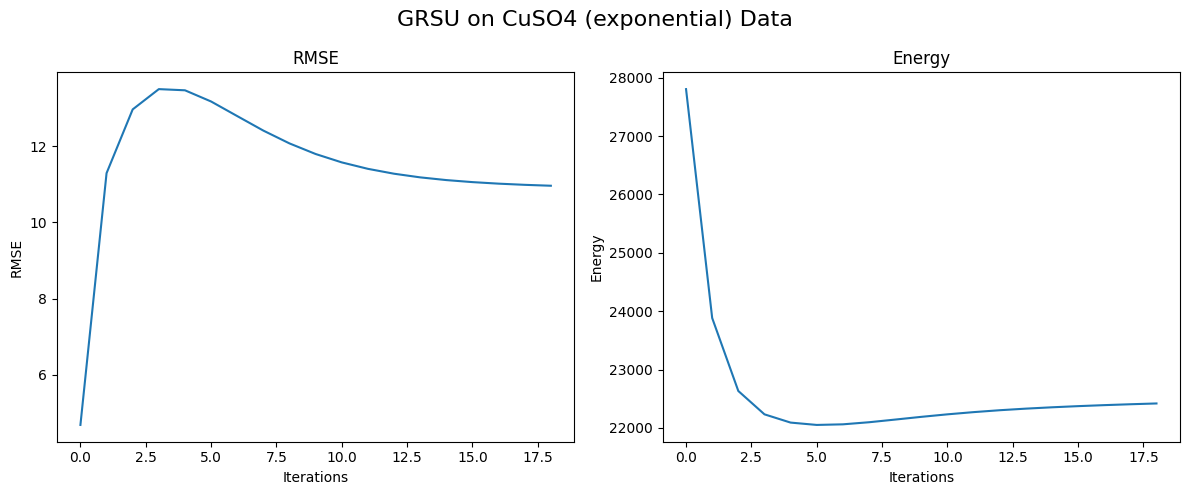

In [4]:
# GRSU (Exact)
# ==========
# Best RMSE + SAD: 33.452971418382745
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 10.0
# RMSE: 10.945612399866981
#  SAD: 22.50735901851576

# Actual Run
A_GRSU_chem, S_GRSU_chem, A_GRSU_RMSE_chem, S_GRSU_RMSE_chem = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 0.01, rho = 10.0, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on CuSO4 (exponential) Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_chem_RMSE, GRSU_chem_energy, __, __ = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                        N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 0.01, rho = 10.0, m_0 = 2, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on CuSO4 (exponential) Data", 
                                                                        prep = None, array_plots = True)

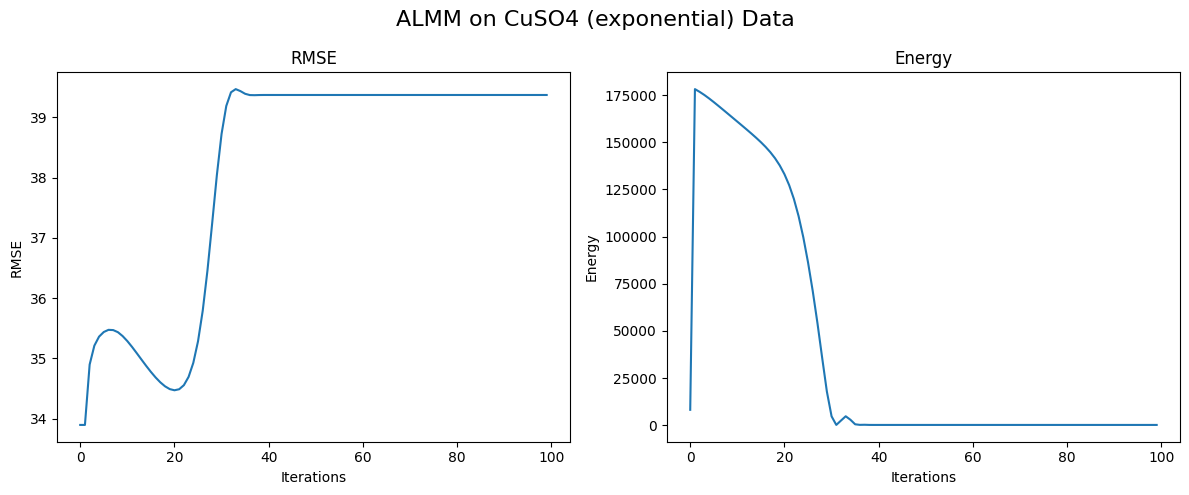

In [5]:
# ALMM
# ==========
# Best RMSE: 39.37278749037893
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

best_alpha = 5.5e-5
best_beta = 5.5e-7
best_gamma = 5.5e-7
best_eta = 5.5e-7

# Actual Run
E_ALMM_chem, A_ALMM_chem, T_ALMM_chem, B_ALMM_chem = algo_2_almm_optimized(X = X_chem, S = S_gt_chem, A_gt = A_gt_chem, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on CuSO4 (exponential) Data", array_plots = False)

# Error and Energy arrays
ALMM_chem_RMSE, ALMM_chem_energy, __, __ = algo_2_almm_optimized(X = X_chem, S = S_gt_chem, A_gt = A_gt_chem, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on CuSO4 (exponential) Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 4.746175764979125
Final Endmember SAD: 31.74438541019793


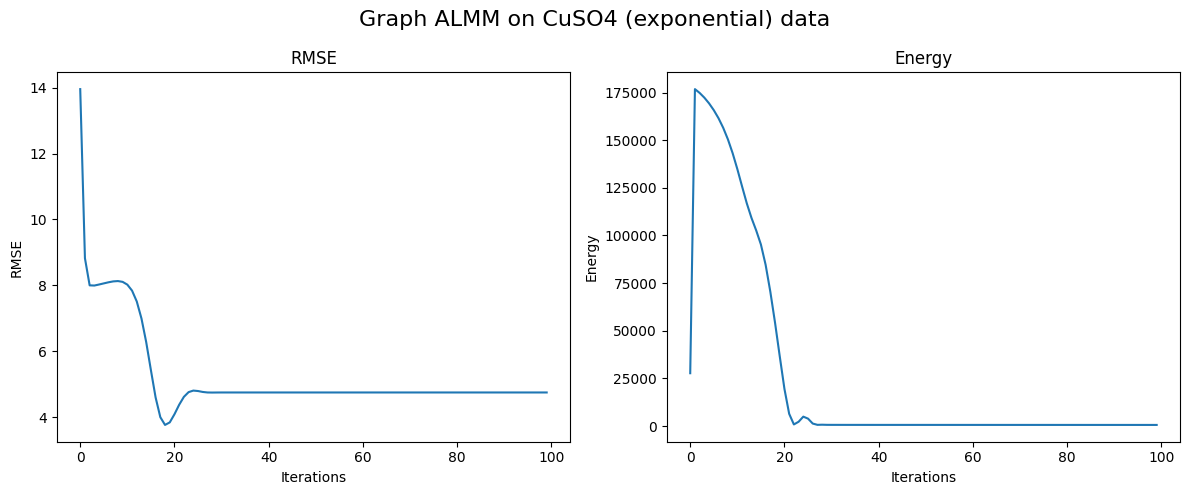

In [6]:
# Graph ALMM
# ==========
# Best RMSE: 4.746174615631578
# Best alpha: 5.499999999999999e-07
# Best M_total: 4.0
# Best xi: 0.1
# Best label: OH

alpha_0 = 5.5e-7
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 1e-1

# Actual Run
A_graph_almm_chem, S_graph_almm_chem, A_rmse_graph_almm_chem, S_rmse_graph_almm_chem = run_unmixing_pipeline_example2(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 4.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on CuSO4 (exponential) data", array_plots = False)

# Error and Energy arrays
graph_almm_chem_RMSE, graph_almm_chem_energy, __, __ = run_unmixing_pipeline_example2(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 4.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = False, 
                                                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on CuSO4 (exponential) data", array_plots = True)

### Abundance Plot

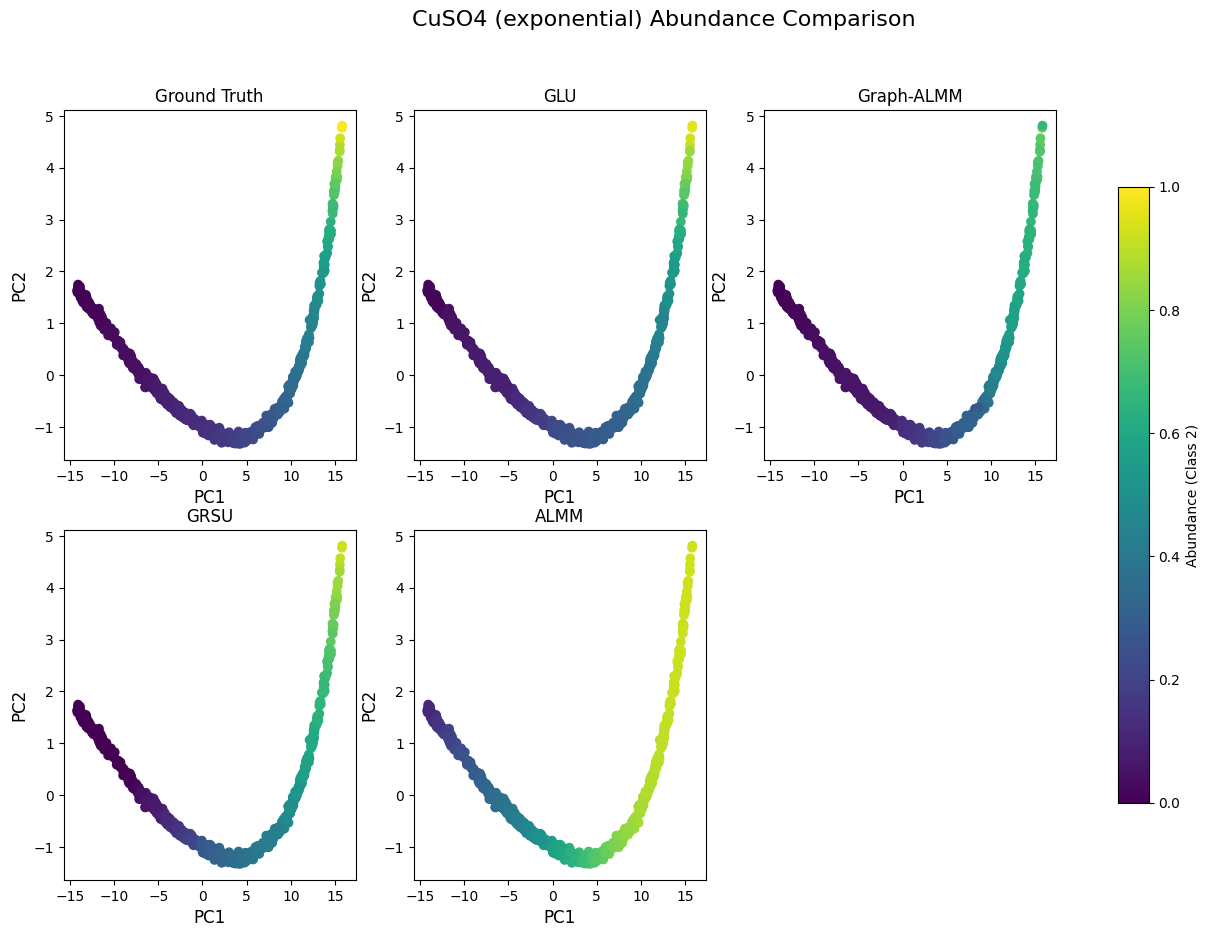

In [7]:
abundance_plotting(X = X_chem, A_gt = A_gt_chem, 
                   A_f_GLU = A_GLU_chem, A_f_GRSU = A_GRSU_chem, A_f_ALMM = A_ALMM_chem, A_f_Graph_ALMM = A_graph_almm_chem, 
                   title = 'CuSO4 (exponential) Abundance Comparison', color_title = 'Abundance (Class 2)')

### Error and Energy plots

In [8]:
# Define data arrays of tuples
chem_RMSE = [
    ("GLU", A_GLU_RMSE_chem),
    ("GRSU", GRSU_chem_RMSE),
    ("ALMM", ALMM_chem_RMSE),
    ("Graph-ALMM", graph_almm_chem_RMSE),
]

chem_energy = [
    ("GLU", GLU_chem_energy),
    ("GRSU", GRSU_chem_energy),
    ("ALMM", ALMM_chem_energy),
    ("Graph-ALMM", graph_almm_chem_energy),
]

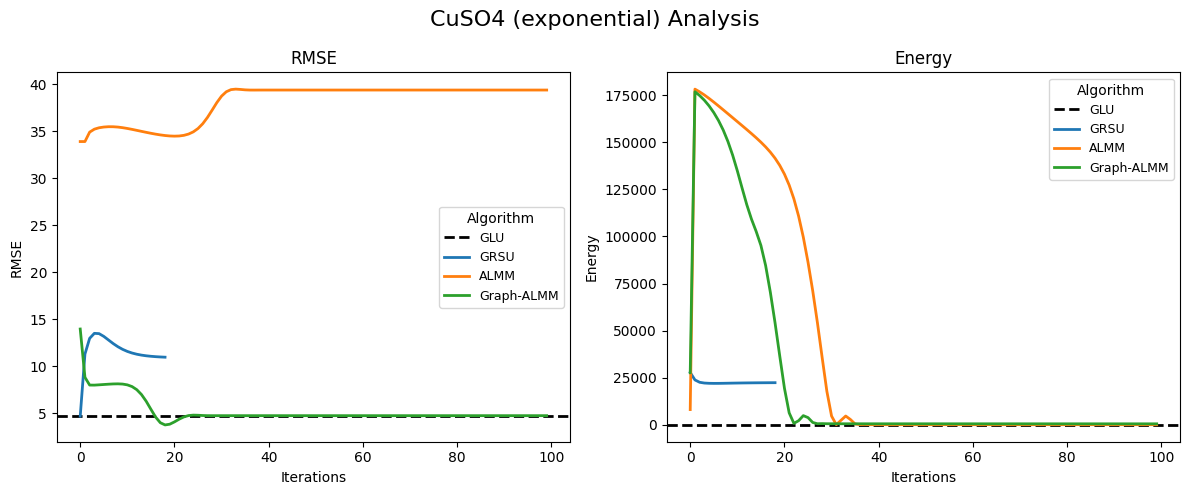

In [9]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = chem_RMSE, Energy_data = chem_energy, title_0 = "CuSO4 (exponential) Analysis")

## FeSO4

### Quick param testing

In [72]:
# GLU

# Best RMSE + SAD: 12.437524085482382
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# alpha_vals = np.array([10, 20, 50, 100])
# lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
# gamma_vals = 10.0 ** np.arange(-2, 3)
# rho_vals = 10.0 ** np.arange(-2, 3)

# parameter_testing(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, N = samples, 
#                   iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
#                   print_bool = False, GRSU_bool = False, OH_labels = True)

In [73]:
# GRSU (OH)

# Best RMSE + SAD: 6.9817391724121745
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 10.0
# Best rho: 1.0

# alpha_vals = np.array([10, 20, 50, 100])
# lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
# gamma_vals = 10.0 ** np.arange(-2, 3)
# rho_vals = 10.0 ** np.arange(-2, 3)

# parameter_testing(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, N = samples, 
#                   iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
#                   print_bool = False, GRSU_bool = True, OH_labels = True)

### Algorithm 

#### Param Test Results

In [74]:
# ==========================================
# Testing on FeSO4
# ==========================================
# Running consistency check (expect ~14)...
# Sanity check result: 36.696125444848846


# GLU (OH)
# ==========
# Best RMSE + SAD: 36.515271574889276
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 30.197395353637695
#  SAD: 6.317876221251578

# GLU (Exact)
# ==========
# Best RMSE + SAD: 26.93875284971625
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 23.283977789949503
#  SAD: 3.654775059766746


# GRSU (OH)
# ==========
# Best RMSE + SAD: 20.24979636425259
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 100.0
# RMSE: 15.818437349923991
#  SAD: 4.431359014328598

# GRSU (Exact)
# ==========
# Best RMSE + SAD: 5.556411629751844
# Best alpha: 10
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 0.01
# RMSE: 2.0533803818690957
#  SAD: 3.503031247882748


# ALMM
# ==========
# Best RMSE: 16.236957499744047
# Best alpha: 0.0005499999999999999
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07


# Graph ALMM
# ==========
# Best RMSE: 4.897011299347826
# Best alpha: 0.0055
# Best M_total: 12.0
# Best xi: 10
# Best label: Exact

#### Tests

GRSU did the best here :( (probably because the data is close to linear). All RMSE's are pretty consistent

In [10]:
# GLU (Exact)
# ==========
# Best RMSE + SAD: 26.93875284971625
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 23.283977789949503
#  SAD: 3.654775059766746

# Actual Run
A_GLU_chem_FeSO4, S_GLU_chem_FeSO4, A_GLU_RMSE_chem_FeSO4, S_GLU_RMSE_chem_FeSO4 = run_unmixing_pipeline_example(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on FeSO4 Chem Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_chem_FeSO4_energy, __, __, __ = run_unmixing_pipeline_example(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, 
                                                                N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                print_bool = False, OH_labels = False, GRSU_bool = False, 
                                                                A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on FeSO4 Chem Data", 
                                                                prep = None, array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 23.177503958136583
Final Endmember SAD: 3.7512137505163157


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 1.6693837813967691
Final Endmember SAD: 3.2562687220901725


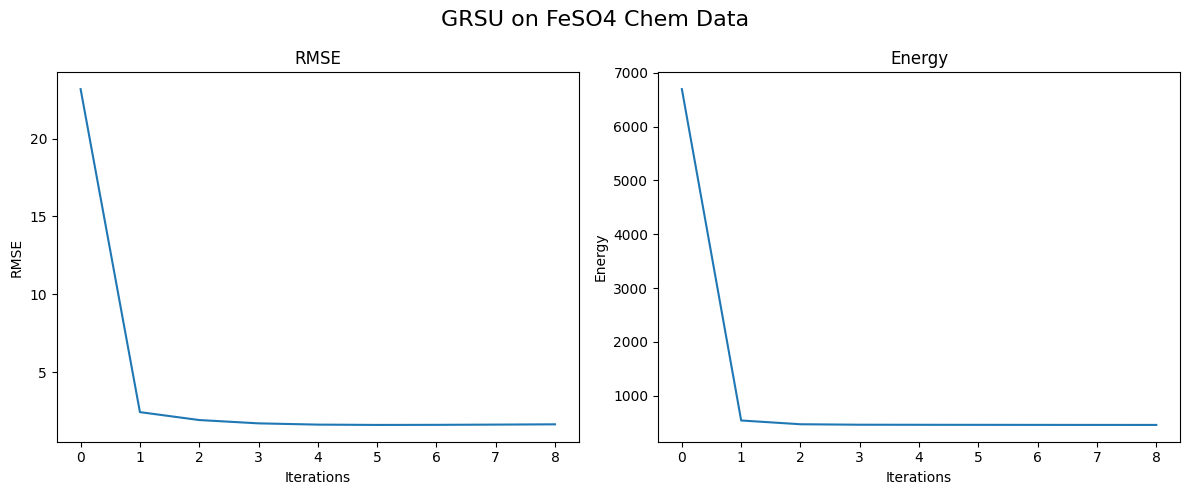

In [11]:
# GRSU (Exact)
# ==========
# Best RMSE + SAD: 5.556411629751844
# Best alpha: 10
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 0.01
# RMSE: 2.0533803818690957
#  SAD: 3.503031247882748

# Actual Run
A_GRSU_chem_FeSO4, S_GRSU_chem_FeSO4, A_GRSU_RMSE_chem_FeSO4, S_GRSU_RMSE_chem_FeSO4 = run_unmixing_pipeline_example(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 100.0, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on FeSO4 Chem Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_chem_FeSO4_RMSE, GRSU_chem_FeSO4_energy, __, __ = run_unmixing_pipeline_example(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, 
                                                                        N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 100.0, rho = 0.01, m_0 = 2, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on FeSO4 Chem Data", 
                                                                        prep = None, array_plots = True)

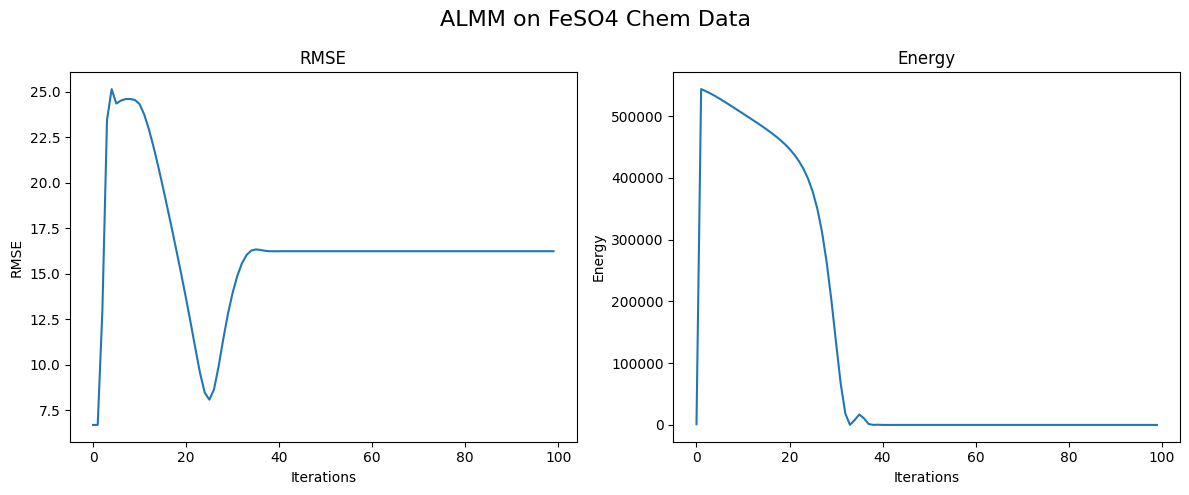

In [12]:
# ALMM
# ==========
# Best RMSE: 16.236957499744047
# Best alpha: 0.0005499999999999999
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

best_alpha = 0.00055
best_beta = 5.5e-7
best_gamma = 5.5e-7
best_eta = 5.5e-7

# Actual Run
E_ALMM_chem_FeSO4, A_ALMM_chem_FeSO4, T_ALMM_chem_FeSO4, B_ALMM_chem_FeSO4 = algo_2_almm_optimized(X = X_chem_FeSO4, S = S_gt_chem_FeSO4, A_gt = A_gt_chem_FeSO4, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on FeSO4 Chem Data", array_plots = False)

# Error and Energy arrays
ALMM_chem_FeSO4_RMSE, ALMM_chem_FeSO4_energy, __, __ = algo_2_almm_optimized(X = X_chem_FeSO4, S = S_gt_chem_FeSO4, A_gt = A_gt_chem_FeSO4, 
                                                                    alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                    maxIter = iters,
                                                                    A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on FeSO4 Chem Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 5.625752189382883
Final Endmember SAD: 3.6304377676222686


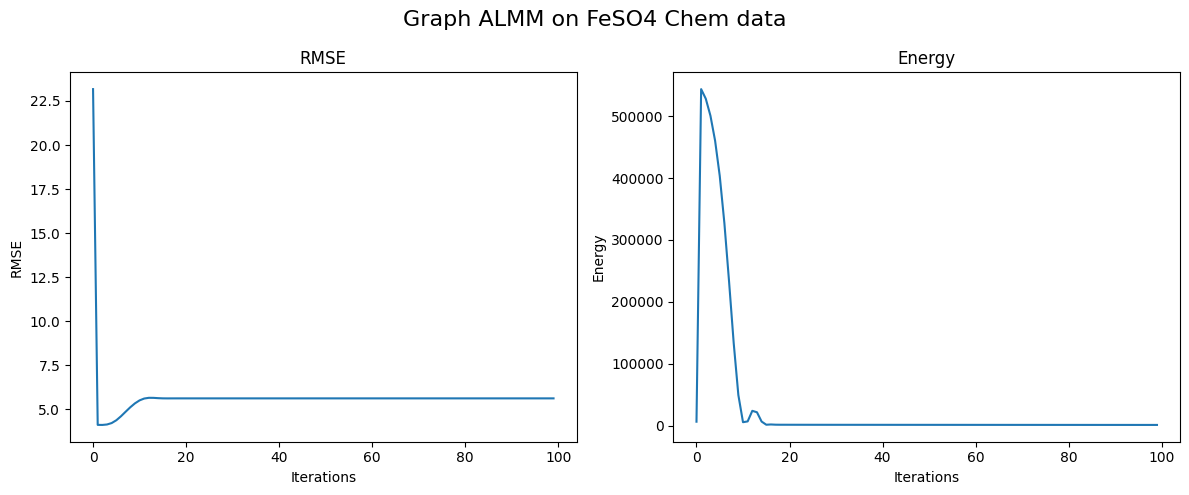

In [13]:
# Graph ALMM
# ==========
# Best RMSE: 4.897011299347826
# Best alpha: 0.0055
# Best M_total: 12.0
# Best xi: 10
# Best label: Exact

alpha_0 = 0.0055
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 10

# Actual Run
A_graph_almm_chem_FeSO4, S_graph_almm_chem_FeSO4, A_rmse_graph_almm_chem_FeSO4, S_rmse_graph_almm_chem_FeSO4 = run_unmixing_pipeline_example2(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 12.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on FeSO4 Chem data", array_plots = False)

# Error and Energy arrays
graph_almm_chem_FeSO4_RMSE, graph_almm_chem_FeSO4_energy, __, __ = run_unmixing_pipeline_example2(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, N = samples, 
                                                                                    alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                    M_total_0 = 12.0, m_0 = 2, xi_0 = xi_0, 
                                                                                    OH_labels = False, print_bool = False, 
                                                                                    A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on FeSO4 Chem data", array_plots = True)

### Abundance plot

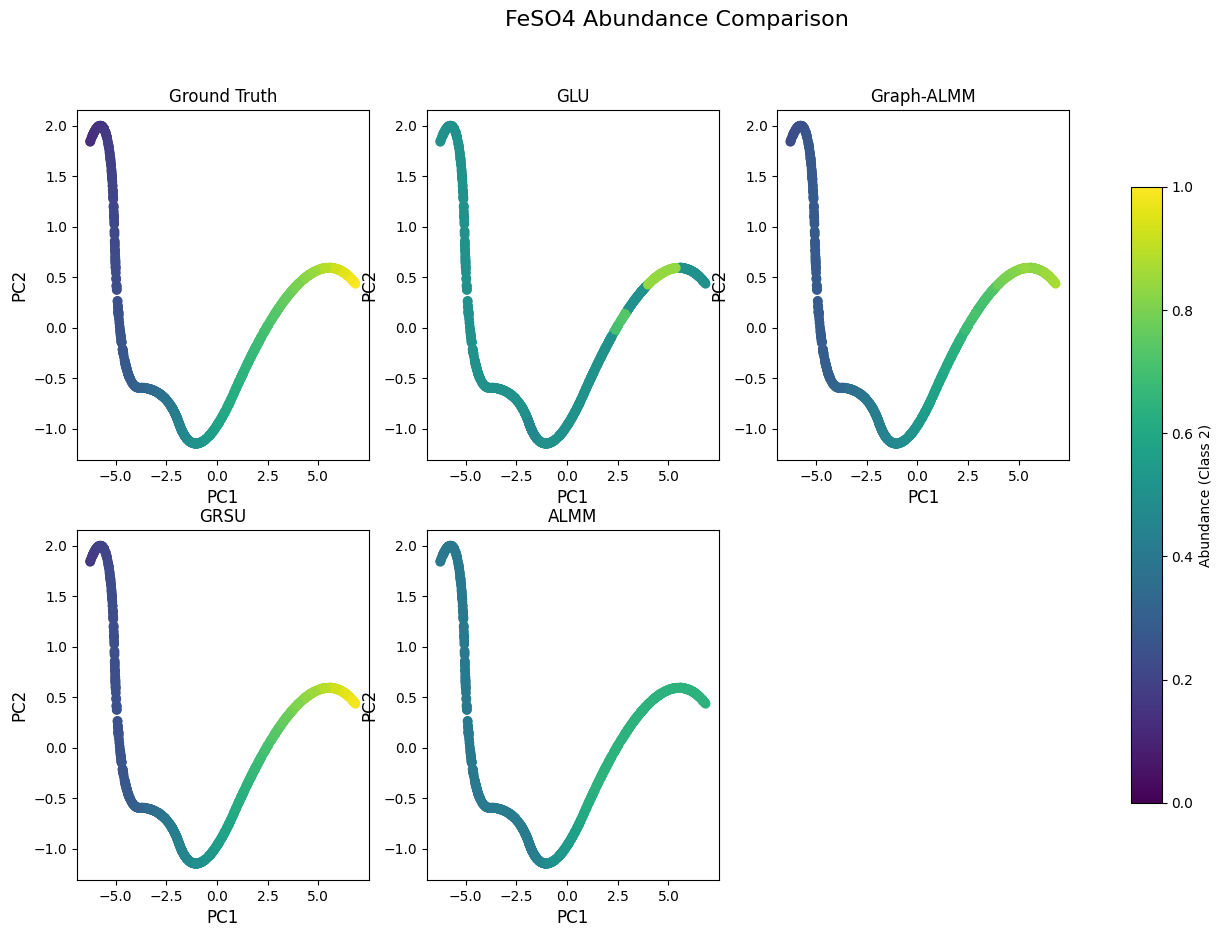

In [14]:
abundance_plotting(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, 
                   A_f_GLU = A_GLU_chem_FeSO4, A_f_GRSU = A_GRSU_chem_FeSO4, A_f_ALMM = A_ALMM_chem_FeSO4, A_f_Graph_ALMM = A_graph_almm_chem_FeSO4, 
                   title = 'FeSO4 Abundance Comparison', color_title = 'Abundance (Class 2)')

### RMSE and Energy Plots

In [15]:
# Define data arrays of tuples
FeSO4_RMSE = [
    ("GLU", A_GLU_RMSE_chem_FeSO4),
    ("GRSU", GRSU_chem_FeSO4_RMSE),
    ("ALMM", ALMM_chem_FeSO4_RMSE),
    ("Graph-ALMM", graph_almm_chem_FeSO4_RMSE),
]

FeSO4_energy = [
    ("GLU", GLU_chem_FeSO4_energy),
    ("GRSU", GRSU_chem_FeSO4_energy),
    ("ALMM", ALMM_chem_FeSO4_energy),
    ("Graph-ALMM", graph_almm_chem_FeSO4_energy),
]

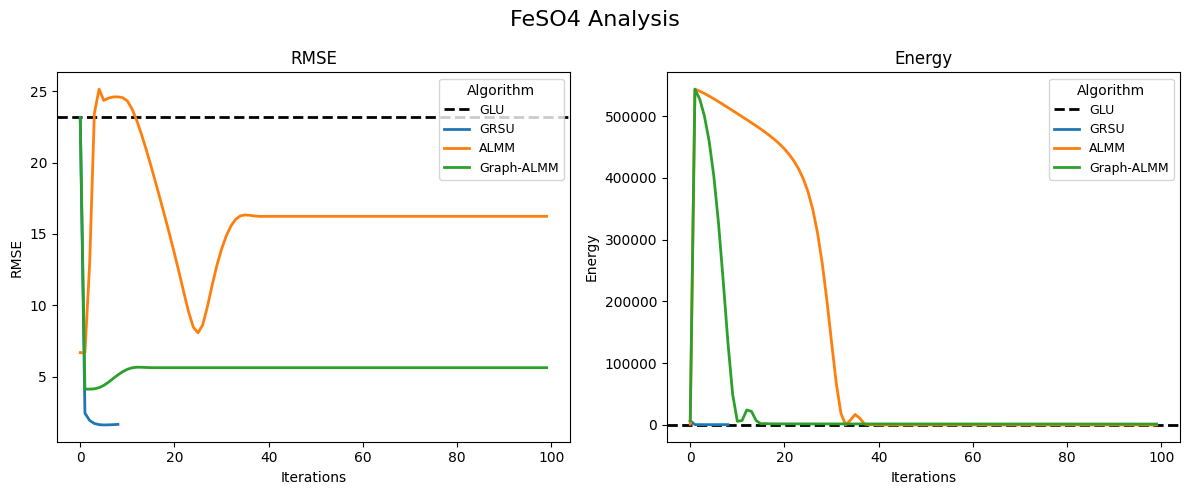

In [16]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = FeSO4_RMSE, Energy_data = FeSO4_energy, title_0 = "FeSO4 Analysis")

## CuSO4

### Algorithm

#### Param Test Results

In [81]:
# ==========================================
# Testing on CuSO4
# ==========================================


# GLU (OH)
# ==========
# Best RMSE + SAD: 68.76333277658023
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 30.061685425481986
#  SAD: 38.701647351098245

# GLU (Exact)
# ==========
# Best RMSE + SAD: 63.04969431018213
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 26.45709235343139
#  SAD: 36.59260195675075


# GRSU (OH)
# ==========
# Best RMSE + SAD: 51.22053414893858
# Best alpha: 10
# Best lambda: 1000
# Best gamma: 0.01
# Best rho: 0.1
# RMSE: 15.145896416760966
#  SAD: 36.074637732177614

# GRSU (Exact)
# ==========
# Best RMSE + SAD: 41.49938716411853
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 100.0
# Best rho: 10.0
# RMSE: 9.013989705650697
#  SAD: 32.48539745846784


# ALMM
# ==========
# Best RMSE: 37.525918595019725
# Best alpha: 5.499999999999999e-07
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07


# Graph ALMM
# ==========
# Best RMSE: 6.9815130948515645
# Best alpha: 0.0055
# Best M_total: 4.0
# Best xi: 1
# Best label: Exact

#### Tests

The RMSE values are mostly consistent, but only Graph-ALMM was not close (still better than GRSU and ALMM though).

In [17]:
# GLU (Exact)
# ==========
# Best RMSE + SAD: 63.04969431018213
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 26.45709235343139
#  SAD: 36.59260195675075

# Actual Run
A_GLU_CuSO4, S_GLU_CuSO4, A_GLU_RMSE_CuSO4, S_GLU_RMSE_CuSO4 = run_unmixing_pipeline_example(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, S_gt = S_gt_chem_CuSO4, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "GLU on CuSO4 Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_CuSO4_energy, __, __, __ = run_unmixing_pipeline_example(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, S_gt = S_gt_chem_CuSO4, 
                                                        N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                        print_bool = False, OH_labels = False, GRSU_bool = False, 
                                                        A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "GLU on CuSO4 Data", 
                                                        prep = None, array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 26.870493790638704
Final Endmember SAD: 34.68336025630995


Building initial graph for Active Learning...


Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 9.842126007815704
Final Endmember SAD: 31.187408102454647


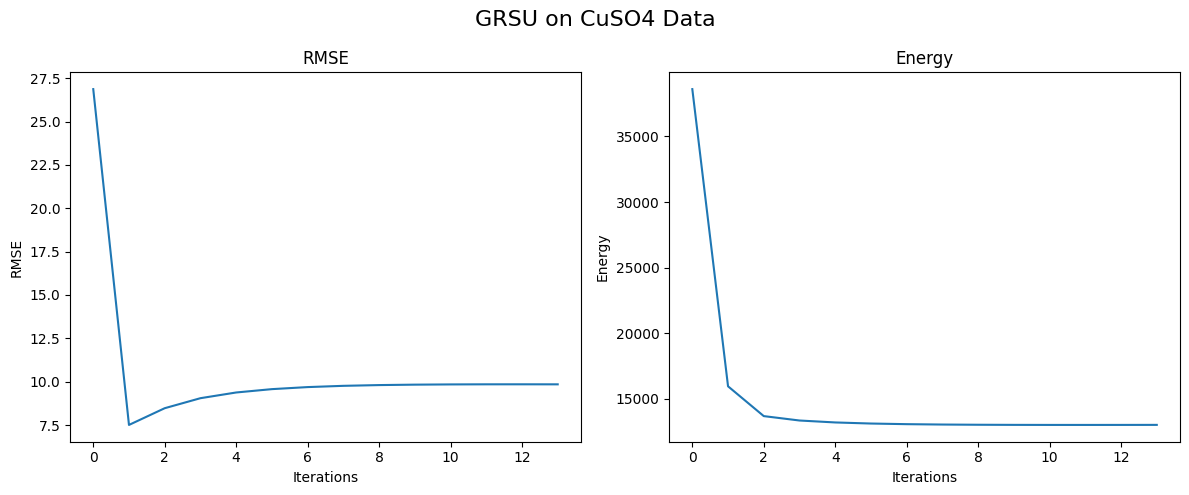

In [18]:
# GRSU (Exact)
# ==========
# Best RMSE + SAD: 41.49938716411853
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 100.0
# Best rho: 10.0
# RMSE: 9.013989705650697
#  SAD: 32.48539745846784

# Actual Run
A_GRSU_CuSO4, S_GRSU_CuSO4, A_GRSU_RMSE_CuSO4, S_GRSU_RMSE_CuSO4 = run_unmixing_pipeline_example(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, S_gt = S_gt_chem_CuSO4, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 100.0, rho = 10.0, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on CuSO4 Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_CuSO4_RMSE, GRSU_CuSO4_energy, __, __ = run_unmixing_pipeline_example(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, S_gt = S_gt_chem_CuSO4, 
                                                                            N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 100.0, rho = 10.0, m_0 = 2, 
                                                                            print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on CuSO4 Data", 
                                                                            prep = None, array_plots = True)


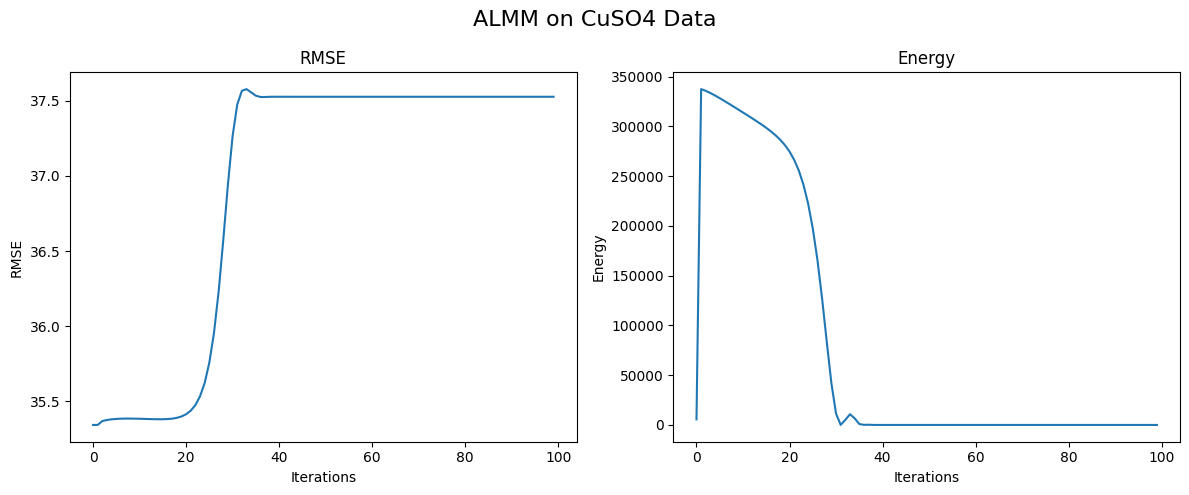

In [19]:
# ALMM
# ==========
# Best RMSE: 37.525918595019725
# Best alpha: 5.499999999999999e-07
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

# Actual Run
E_ALMM_CuSO4, A_ALMM_CuSO4, T_ALMM_CuSO4, B_ALMM_CuSO4 = algo_2_almm_optimized(X = X_chem_CuSO4, S = S_gt_chem_CuSO4, A_gt = A_gt_chem_CuSO4, 
                                                                            alpha = 5.5e-7, beta = 5.5e-7, gamma = 5.5e-7, eta = 5.5e-7, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on CuSO4 Data", array_plots = False)

# Error and Energy arrays
ALMM_CuSO4_RMSE, ALMM_CuSO4_energy, __, __ = algo_2_almm_optimized(X = X_chem_CuSO4, S = S_gt_chem_CuSO4, A_gt = A_gt_chem_CuSO4, 
                                                                    alpha = 5.5e-7, beta = 5.5e-7, gamma = 5.5e-7, eta = 5.5e-7, 
                                                                    maxIter = iters,
                                                                    A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on CuSO4 Data", array_plots = True)                                                                            

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 9.324211806264133
Final Endmember SAD: 33.03747752284591


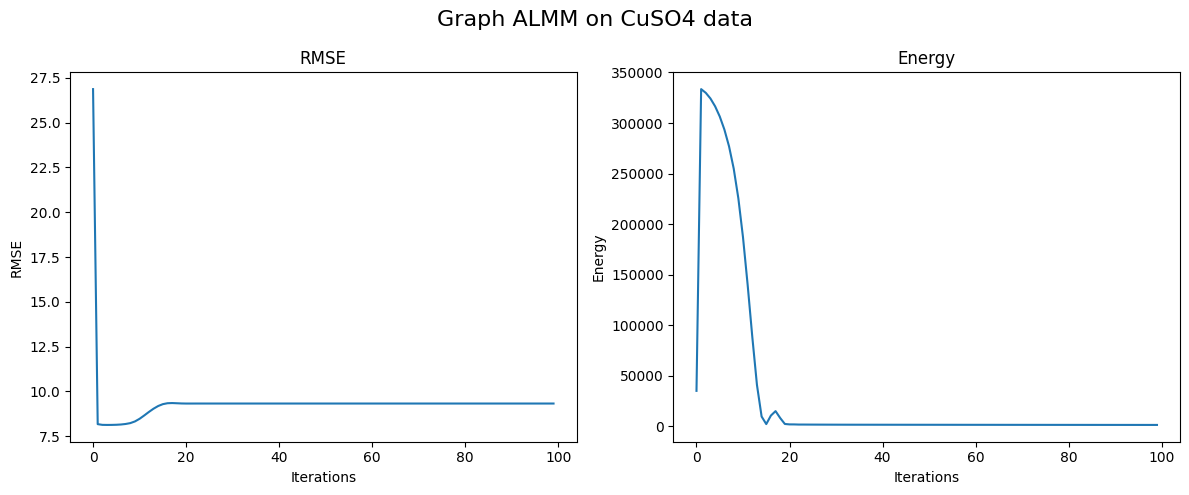

In [20]:
# Graph ALMM
# ==========
# Best RMSE: 6.9815130948515645
# Best alpha: 0.0055
# Best M_total: 4.0
# Best xi: 1
# Best label: Exact

beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2

# Actual run
A_graph_almm_CuSO4, S_graph_almm_CuSO4, A_rmse_graph_almm_CuSO4, S_rmse_graph_almm_CuSO4 = run_unmixing_pipeline_example2(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, S_gt = S_gt_chem_CuSO4, N = samples, 
                                                                                                                        alpha = 0.0055, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 4.0, m_0 = 2, xi_0 = 1, 
                                                                                                                        OH_labels = False, print_bool = True,
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on CuSO4 data", array_plots = False)

# Error and Energy arrays
graph_almm_CuSO4_RMSE, graph_almm_CuSO4_energy, __, __ = run_unmixing_pipeline_example2(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, S_gt = S_gt_chem_CuSO4, N = samples, 
                                                                                        alpha = 0.0055, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                        M_total_0 = 4.0, m_0 = 2, xi_0 = 1, 
                                                                                        OH_labels = False, print_bool = False,
                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on CuSO4 data", array_plots = True) 
        


### Abundance Plot

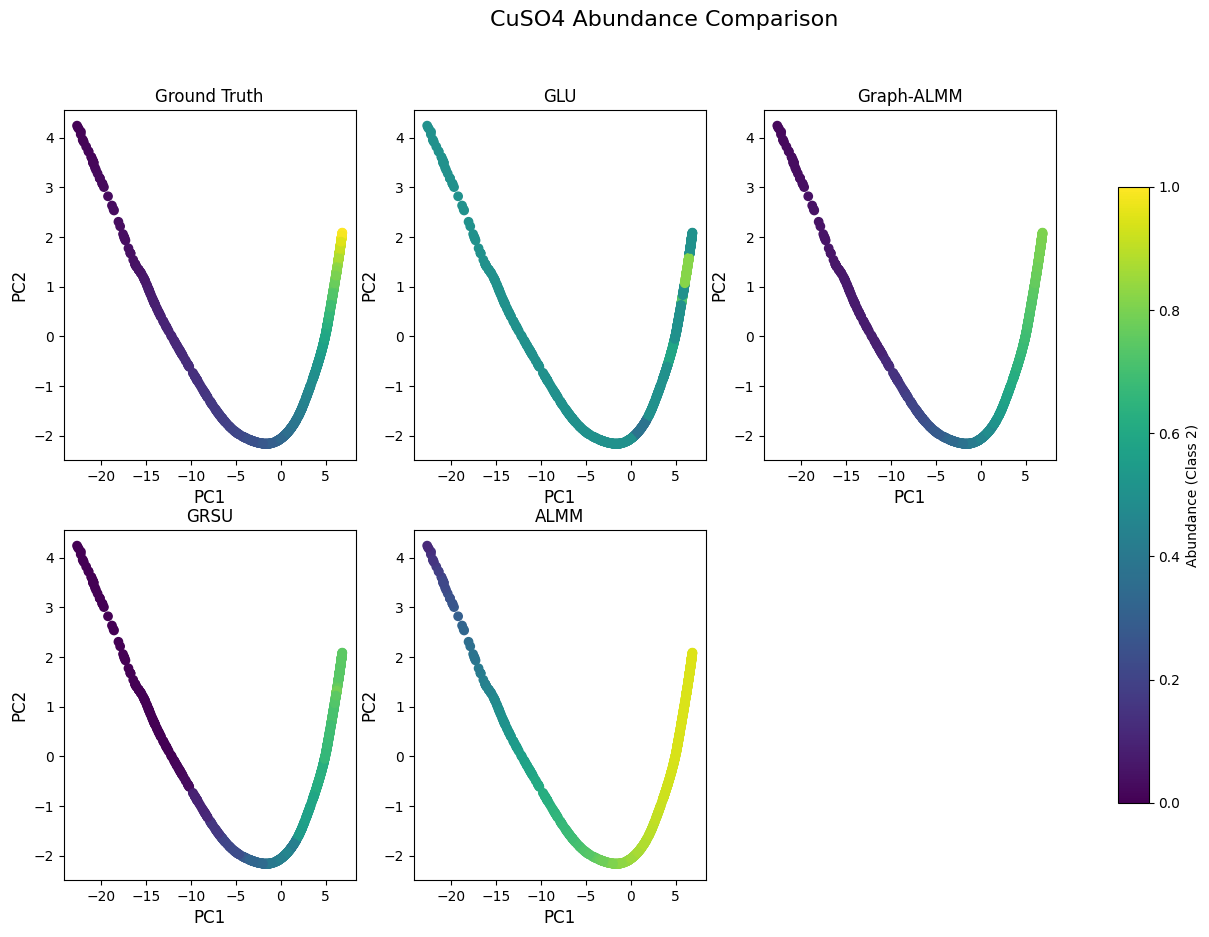

In [21]:
abundance_plotting(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, 
                   A_f_GLU = A_GLU_CuSO4, A_f_GRSU = A_GRSU_CuSO4, A_f_ALMM = A_ALMM_CuSO4, A_f_Graph_ALMM = A_graph_almm_CuSO4, 
                   title = 'CuSO4 Abundance Comparison', color_title = 'Abundance (Class 2)')

### RMSE and Energy plots

In [23]:
# Define data arrays of tuples
CuSO4_RMSE = [
    ("GLU", A_GLU_RMSE_CuSO4),
    ("GRSU", GRSU_CuSO4_RMSE),
    ("ALMM", ALMM_CuSO4_RMSE),
    ("Graph-ALMM", graph_almm_CuSO4_RMSE),
]

CuSO4_energy = [
    ("GLU", GLU_CuSO4_energy),
    ("GRSU", GRSU_CuSO4_energy),
    ("ALMM", ALMM_CuSO4_energy),
    ("Graph-ALMM", graph_almm_CuSO4_energy),
]

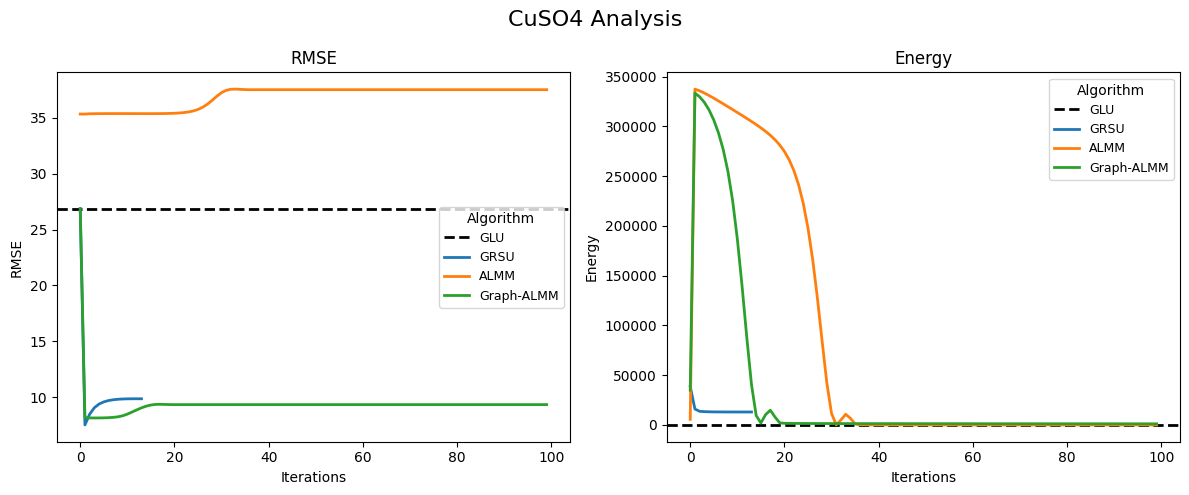

In [24]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = CuSO4_RMSE, Energy_data = CuSO4_energy, title_0 = "CuSO4 Analysis")

## FeCI3

### Algorithm

#### Param Test Results

In [88]:
# ==========================================
# Testing on FeCl3
# ==========================================
# X: (1050, 1000) 
#  S: (1050, 2) 
#  A: (2, 1000)


# GLU (OH)
# ==========
# Best RMSE + SAD: 44.82107581948034
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 28.88227988575932
#  SAD: 15.938795933721021

# GLU (Exact)
# ==========
# Best RMSE + SAD: 38.351071929439165
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 25.914497263066394
#  SAD: 12.436574666372772


# GRSU (OH)
# ==========
# Best RMSE + SAD: 26.659258003780515
# Best alpha: 10
# Best lambda: 1
# Best gamma: 10.0
# Best rho: 100.0
# RMSE: 13.269757046513064
#  SAD: 13.38950095726745

# GRSU (Exact)
# ==========
# Best RMSE + SAD: 16.496320475484413
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 10.0
# Best rho: 100.0
# RMSE: 5.088717901240983
#  SAD: 11.40760257424343


# ALMM
# ==========
# Best RMSE: 22.32901493358215
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07


# Graph ALMM
# ==========
# Best RMSE: 4.606723806504279
# Best alpha: 0.0055
# Best M_total: 8.0
# Best xi: 100
# Best label: Exact


#### Tests

All were pretty consistent

In [25]:
# GLU (Exact)
# ==========
# Best RMSE + SAD: 38.351071929439165
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 25.914497263066394
#  SAD: 12.436574666372772

# Actual Run
A_GLU_FeCl3, S_GLU_FeCl3, A_GLU_RMSE_FeCl3, S_GLU_RMSE_FeCl3 = run_unmixing_pipeline_example(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "GLU on FeCl3 Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_FeCl3_energy, __, __, __ = run_unmixing_pipeline_example(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, 
                                                            N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                            print_bool = False, OH_labels = False, GRSU_bool = False, 
                                                            A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "GLU on FeCl3 Data", 
                                                            prep = None, array_plots = True)



Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 26.111059592860286
Final Endmember SAD: 12.52582544754635


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 4.8286100342235
Final Endmember SAD: 11.301823612243743


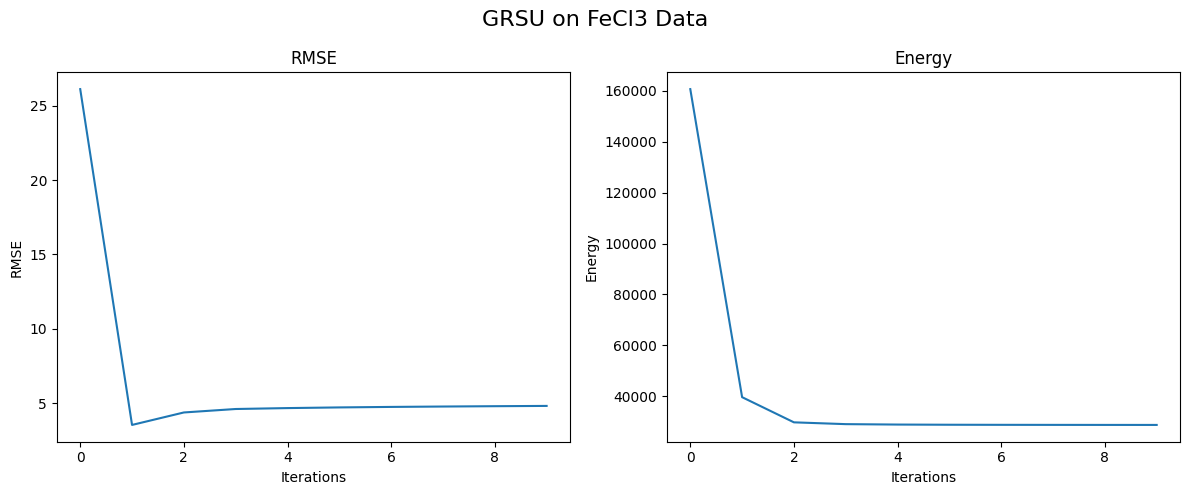

In [26]:
# GRSU (Exact)
# ==========
# Best RMSE + SAD: 16.496320475484413
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 10.0
# Best rho: 100.0
# RMSE: 5.088717901240983
#  SAD: 11.40760257424343

# Actual Run
A_GRSU_FeCl3, S_GRSU_FeCl3, A_GRSU_RMSE_FeCl3, S_GRSU_RMSE_FeCl3 = run_unmixing_pipeline_example(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 10.0, rho = 100.0, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on FeCl3 Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_FeCl3_RMSE, GRSU_FeCl3_energy, __, __ = run_unmixing_pipeline_example(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, 
                                                                            N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 10.0, rho = 100.0, m_0 = 2, 
                                                                            print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on FeCl3 Data", 
                                                                            prep = None, array_plots = True)

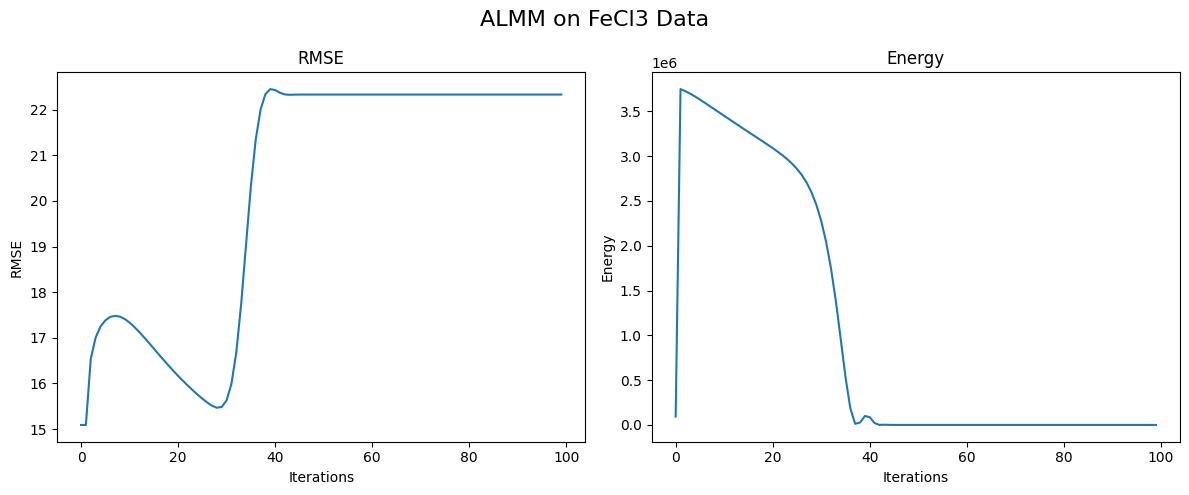

In [27]:
# ALMM
# ==========
# Best RMSE: 22.32901493358215
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

# Actual Run
E_ALMM_FeCl3, A_ALMM_FeCl3, T_ALMM_FeCl3, B_ALMM_FeCl3 = algo_2_almm_optimized(X = X_chem_FeCl3, S = S_gt_chem_FeCl3, A_gt = A_gt_chem_FeCl3, 
                                                                            alpha = 5.5e-5, beta = 5.5e-7, gamma = 5.5e-7, eta = 5.5e-7, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on FeCl3 Data", array_plots = False)

# Error and Energy arrays
ALMM_FeCl3_RMSE, ALMM_FeCl3_energy, __, __ = algo_2_almm_optimized(X = X_chem_FeCl3, S = S_gt_chem_FeCl3, A_gt = A_gt_chem_FeCl3, 
                                                                    alpha = 5.5e-5, beta = 5.5e-7, gamma = 5.5e-7, eta = 5.5e-7, 
                                                                    maxIter = iters,
                                                                    A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on FeCl3 Data", array_plots = True)                                                                        

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 4.669461374121513
Final Endmember SAD: 10.622681757655606


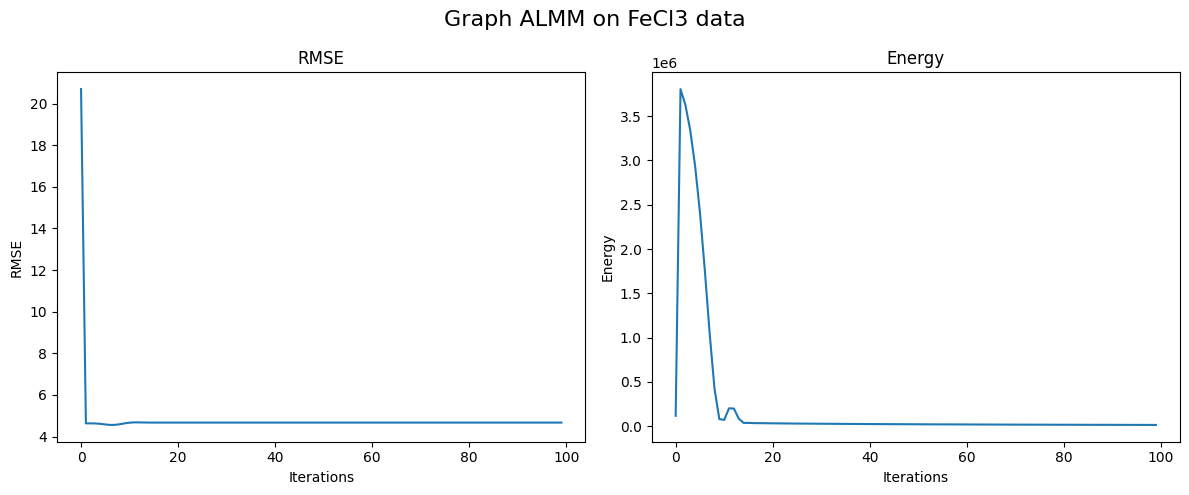

In [28]:
# Graph ALMM
# ==========
# Best RMSE: 4.606723806504279
# Best alpha: 0.0055
# Best M_total: 8.0
# Best xi: 100
# Best label: Exact

beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2

# Actual Run
A_graph_almm_FeCl3, S_graph_almm_FeCl3, A_rmse_graph_almm_FeCl3, S_rmse_graph_almm_FeCl3 = run_unmixing_pipeline_example2(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, N = samples, 
                                                                                                                        alpha = 0.0055, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 8.0, m_0 = 2, xi_0 = 100, 
                                                                                                                        OH_labels = False, print_bool = True,
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on FeCl3 data", array_plots = False) 

# Error and Energy arrays
graph_almm_FeCl3_RMSE, graph_almm_FeCl3_energy, __, __ = run_unmixing_pipeline_example2(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, N = samples, 
                                                                                        alpha = 0.0055, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                        M_total_0 = 8.0, m_0 = 2, xi_0 = 100, 
                                                                                        OH_labels = False, print_bool = False,
                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on FeCl3 data", array_plots = True) 

### Abundance Plot

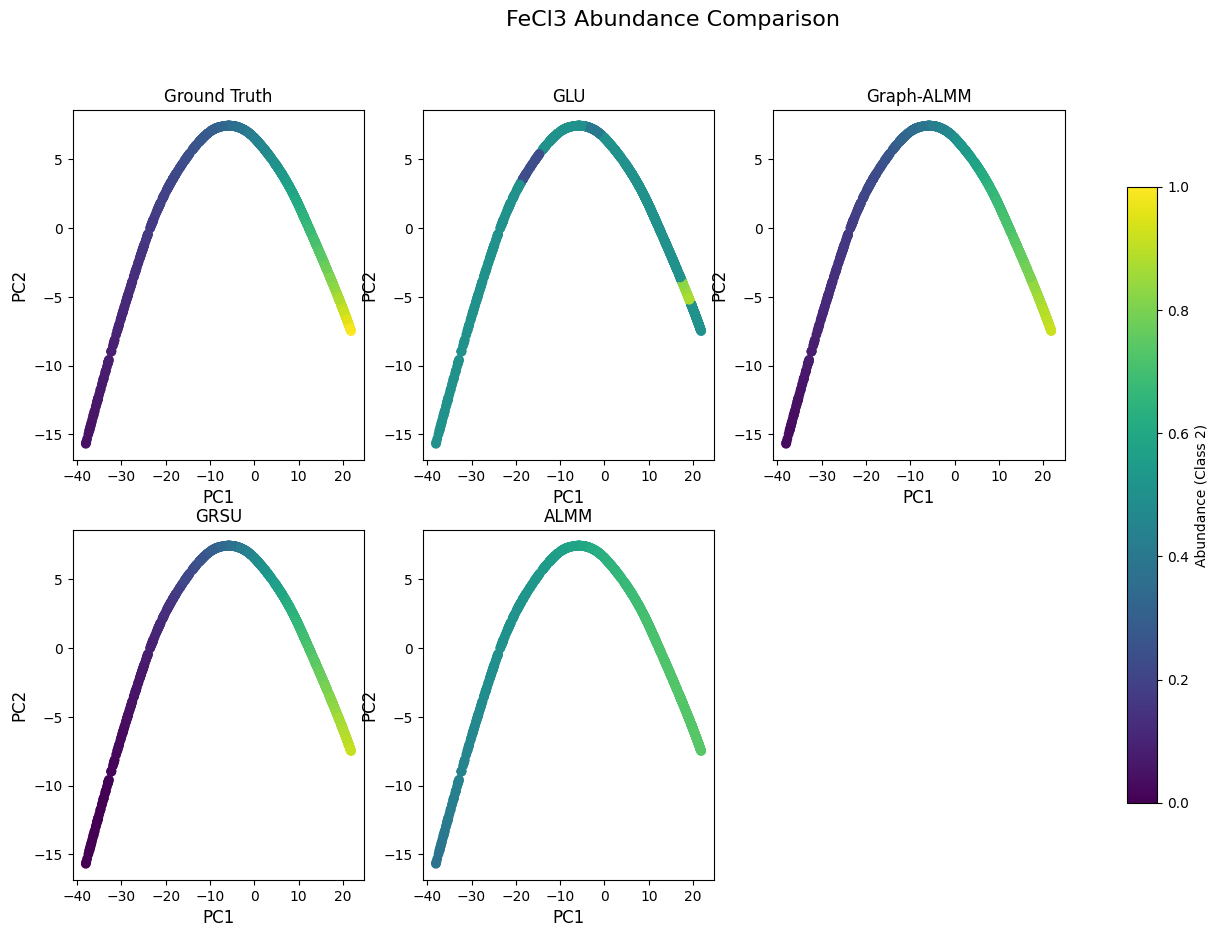

In [35]:
abundance_plotting(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, 
                   A_f_GLU = A_GLU_FeCl3, A_f_GRSU = A_GRSU_FeCl3, A_f_ALMM = A_ALMM_FeCl3, A_f_Graph_ALMM = A_graph_almm_FeCl3, 
                   title = 'FeCl3 Abundance Comparison', color_title = 'Abundance (Class 2)')



### Error and Energy Plots

In [36]:
# Define data arrays of tuples
FeCl3_RMSE = [
    ("GLU", A_GLU_RMSE_FeCl3),
    ("GRSU", GRSU_FeCl3_RMSE),
    ("ALMM", ALMM_FeCl3_RMSE),
    ("Graph-ALMM", graph_almm_FeCl3_RMSE),
]

FeCl3_energy = [
    ("GLU", GLU_FeCl3_energy),
    ("GRSU", GRSU_FeCl3_energy),
    ("ALMM", ALMM_FeCl3_energy),
    ("Graph-ALMM", graph_almm_FeCl3_energy),
]

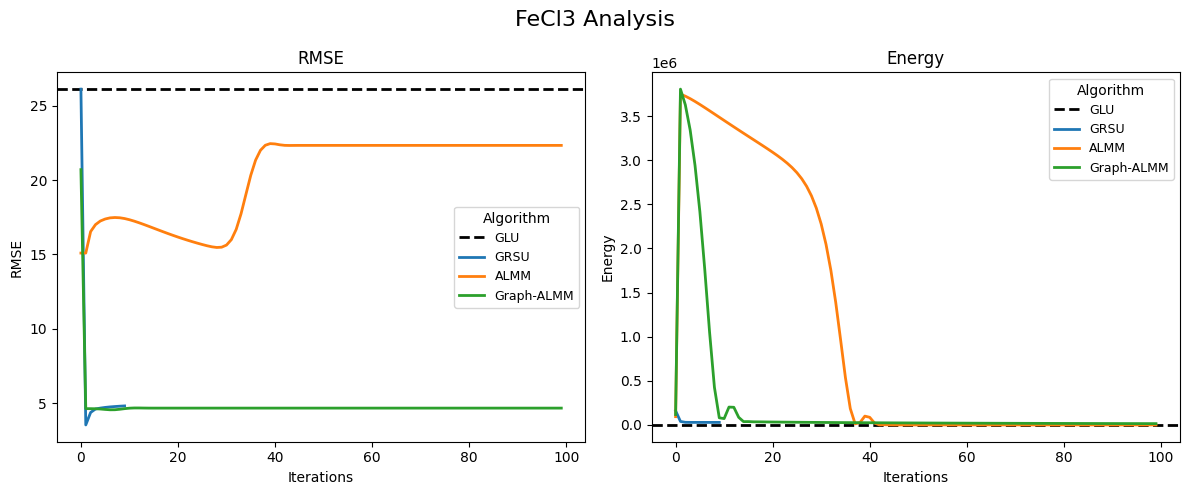

In [37]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = FeCl3_RMSE, Energy_data = FeCl3_energy, title_0 = "FeCl3 Analysis")

## RMSE table

In [38]:
# Calculate RMSE for ALMM
A_ALMM_RMSE_chem = RMSE(A_ALMM_chem, A_gt_chem)
A_ALMM_RMSE_CuSO4 = RMSE(A_ALMM_CuSO4, A_gt_chem_CuSO4)
A_ALMM_RMSE_FeSO4 = RMSE(A_ALMM_chem_FeSO4, A_gt_chem_FeSO4)
A_ALMM_RMSE_FeCl3 = RMSE(A_ALMM_FeCl3, A_gt_chem_FeCl3)

In [39]:
A_rmse_graph_almm_chem_FeSO4

np.float64(5.625752189382883)

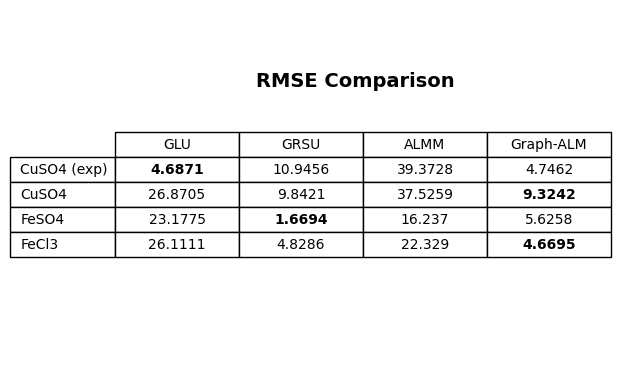

In [41]:


data = np.array([
    [np.round(A_GLU_RMSE_chem, 4), np.round(A_GRSU_RMSE_chem, 4), np.round(A_ALMM_RMSE_chem, 4), np.round(A_rmse_graph_almm_chem, 4)],
    [np.round(A_GLU_RMSE_CuSO4, 4), np.round(A_GRSU_RMSE_CuSO4, 4), np.round(A_ALMM_RMSE_CuSO4, 4), np.round(A_rmse_graph_almm_CuSO4, 4)],
    [np.round(A_GLU_RMSE_chem_FeSO4, 4), np.round(A_GRSU_RMSE_chem_FeSO4, 4), np.round(A_ALMM_RMSE_FeSO4, 4), np.round(A_rmse_graph_almm_chem_FeSO4, 4)],
    [np.round(A_GLU_RMSE_FeCl3, 4), np.round(A_GRSU_RMSE_FeCl3, 4), np.round(A_ALMM_RMSE_FeCl3, 4), np.round(A_rmse_graph_almm_FeCl3, 4)]
])

headers = ["GLU", "GRSU", "ALMM", "Graph-ALM"]
row_headers = ["CuSO4 (exp)", "CuSO4", "FeSO4", "FeCl3"]

fig, ax = plt.subplots()
ax.axis("off")  # hide the plot axes, just want the table

table = ax.table(
    cellText=data,
    colLabels=headers,
    rowLabels=row_headers,
    cellLoc="center",
    loc="center"
)

# bold the min value in each row
for row_idx, row in enumerate(data):
    min_col = np.argmin(row)
    cell = table[row_idx + 1, min_col]  # +1 because row 0 is the header
    cell.set_text_props(weight="bold")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

fig.suptitle("RMSE Comparison", fontsize=14, fontweight="bold", y = 0.75)

plt.savefig("RMSE_table.png", dpi=300, bbox_inches="tight")